In [1]:
import numpy as np
import matplotlib.pyplot as plt

from typing import Literal

from tqdm import tqdm

import torch.nn as nn
import torch.optim as optim

from torch import (
    cuda,

    Tensor,
    tensor,

    device,
    float32
)

cuda_is_available = cuda.is_available()
DEVICE = device('cuda' if cuda_is_available else 'cpu')

DTYPE = float32

In [2]:
from GraphSimulation import (
    TripartiteGraph,
    MatchingStrategy, 
    
    RandomStrategy, 
    GreedyStrategy, 
    RankStrategy, 

    MLPStrategy,
    ResidualMLPStrategy,
    CNNStrategy,
    TimeSeriesStrategy,
    TransformerStrategy
)

from GraphSimulation.utils import LARGE_NUMBER

from GraphSimulation import TripartiteGraphTrainer
from GraphSimulation.GraphAITrainer import (
    VanillaPolicyGradient
)

c:\Users\anshu_r9i5971\Desktop\Python\Capstone\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
n_Inodes = 100
n_Lnodes = 100
n_Rnodes = 100

OPTIMAL = min(n_Lnodes, n_Inodes, n_Rnodes)
RESULTS = {}

In [4]:
def generate_varNodes(inode_ids, n_Lnodes, n_Inodes, n_Rnodes, shuffle=False, seed= None,
                    lb:int=1, ub:int|None=None):
    rand_gen = np.random.default_rng(seed)
    nodes = []

    if(not ub): ub = n_Inodes + 1

    # Generate L nodes
    for _ in range(n_Lnodes):
        k = rand_gen.integers(lb, ub)
        candidates = rand_gen.choice(inode_ids, size=k, replace=False).tolist()
        nodes.append(("L", candidates))

    # Generate R nodes
    for _ in range(n_Rnodes):
        k = rand_gen.integers(lb, ub)
        candidates = rand_gen.choice(inode_ids, size=k, replace=False).tolist()
        nodes.append(("R", candidates))

    if shuffle: rand_gen.shuffle(nodes)
    return nodes

def simulate_online(graph: TripartiteGraph, node_order):
    for time, (node_type, candidates) in enumerate(node_order):
        if node_type == "L":
            graph.add_Lnode(time, candidates)
        else:
            graph.add_Rnode(time, candidates)
    return graph.matches

In [5]:
def run_experiment(arg:TripartiteGraph|MatchingStrategy, 
                runs=100, 
                n_inodes= n_Inodes, n_lnodes=n_Lnodes, n_rnodes=n_Rnodes, 
                seed:int|None= None, results:dict= RESULTS, lb= 1, ub= None):
    results_online = []
    rand_gen = np.random.default_rng(seed)

    # Handle the Graph
    if(isinstance(arg, TripartiteGraph)):
        g = arg
    elif(isinstance(arg, MatchingStrategy)):
        g = TripartiteGraph(arg, n_inodes)
    else:
        print("No Graph or Strategy provided for experiment")
        return

    inode_ids = list(g.Inodes.keys())

    # Generate the nodes order
    node_order = generate_varNodes(inode_ids,
                        n_lnodes, n_inodes, n_rnodes, seed=seed, lb=lb, ub=ub)

    pbar = tqdm(range(runs), desc=f'Simulating: {g.strategy.name}')
    for _ in pbar:
        # Shuffle Nodes
        rand_gen.shuffle(node_order)

        # Online
        matches_online = simulate_online(g, node_order)
        results_online.append(matches_online)

        # Reset Graph
        g.reset()
    results[g.strategy.name] = results_online

## Supervised Training

In [6]:
GLOBAL_EPOCHS = 200

In [7]:
class SupervisedPolicyLoss(nn.Module):
    def __init__(self):
        super().__init__()

        self.CE = nn.CrossEntropyLoss()

    def forward(self, pred: Tensor, true: Tensor):
        # -------- Hard target (CE) --------
        target_idx = true.argmax(dim=1)
        ce_true_loss = self.CE(pred, target_idx)

        # -------- Combine --------
        loss = ce_true_loss
        return loss

In [8]:
# Teacher (strong heuristic)
teacher = RankStrategy(deterministic_partner= True)

trainer = TripartiteGraphTrainer(
    n_Inodes=n_Inodes, 
    criterion=SupervisedPolicyLoss(),

    beta= 0.0
)
trainer.set_teacher(teacher)

RL_policy = VanillaPolicyGradient()
trainer.set_rl_policy(RL_policy)

def train_models(trainer: TripartiteGraphTrainer, models: tuple, mode: Literal["SV", "RL"]= "SV",
                epochs= GLOBAL_EPOCHS, epoch_per_graph: int|None = 25, 
                seed:int = 0, lb=1, ub=None, verbose= False):
    rnd_gen = np.random.default_rng(seed)
    
    if(not epoch_per_graph): epoch_per_graph = epochs
    net_epoch = int(max(1, epochs / epoch_per_graph))

    for _ in range(net_epoch):
        train_seed = rnd_gen.integers(int(LARGE_NUMBER))
        train_node_order = generate_varNodes(range(n_Inodes), n_Lnodes, n_Inodes, n_Rnodes, 
                                            seed=train_seed, lb=lb, ub=ub)

        for model in models:
            optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay= 1e-5)
            trainer.set_student(model, optimizer)

            if(mode == "SV"):
                trainer.train_supervised(train_node_order, epochs= epoch_per_graph, verbose= verbose)
            else:
                trainer.train_rl(train_node_order, epochs= epoch_per_graph, verbose= verbose)
        print(f"Training done on GraphSeed: {train_seed}")

In [9]:
# Student (AI)
models = (
    MLPStrategy(),
    ResidualMLPStrategy(),
    CNNStrategy(),
    TimeSeriesStrategy(),
    TransformerStrategy(),
)

# Student_RL (AI)
rl_models = (
    MLPStrategy(),
    ResidualMLPStrategy(),
    CNNStrategy(),
    TimeSeriesStrategy(),
    TransformerStrategy(),
)

for model in rl_models:
    model.name += "_RL"

In [10]:
train_models(trainer, models)

Model saved to ./models/MLPStrategy.pth
Training done
Model saved to ./models/ResidualMLPStrategy.pth
Training done
Model saved to ./models/CNNStrategy.pth
Training done
Model saved to ./models/TimeSeriesStrategy.pth
Training done
Model saved to ./models/TransformerStrategy.pth
Training done
Training done on GraphSeed: 850624225
Model saved to ./models/MLPStrategy.pth
Training done
Model saved to ./models/ResidualMLPStrategy.pth
Training done
Model saved to ./models/CNNStrategy.pth
Training done
Model saved to ./models/TimeSeriesStrategy.pth
Training done
Model saved to ./models/TransformerStrategy.pth
Training done
Training done on GraphSeed: 636961687
Model saved to ./models/MLPStrategy.pth
Training done
Model saved to ./models/ResidualMLPStrategy.pth
Training done
Model saved to ./models/CNNStrategy.pth
Training done
Model saved to ./models/TimeSeriesStrategy.pth
Training done
Model saved to ./models/TransformerStrategy.pth
Training done
Training done on GraphSeed: 511136479
Model s

In [11]:
train_models(trainer, rl_models, mode= "RL")

Model saved to ./models/MLPStrategy_RL.pth
RL Training done
Model saved to ./models/ResidualMLPStrategy_RL.pth
RL Training done
Model saved to ./models/CNNStrategy_RL.pth
RL Training done
Model saved to ./models/TimeSeriesStrategy_RL.pth
RL Training done
Model saved to ./models/TransformerStrategy_RL.pth
RL Training done
Training done on GraphSeed: 850624225
Model saved to ./models/MLPStrategy_RL.pth
RL Training done
Model saved to ./models/ResidualMLPStrategy_RL.pth
RL Training done
Model saved to ./models/CNNStrategy_RL.pth
RL Training done
Model saved to ./models/TimeSeriesStrategy_RL.pth
RL Training done
Model saved to ./models/TransformerStrategy_RL.pth
RL Training done
Training done on GraphSeed: 636961687
Model saved to ./models/MLPStrategy_RL.pth
RL Training done
Model saved to ./models/ResidualMLPStrategy_RL.pth
RL Training done
Model saved to ./models/CNNStrategy_RL.pth
RL Training done
Model saved to ./models/TimeSeriesStrategy_RL.pth
RL Training done
Model saved to ./models

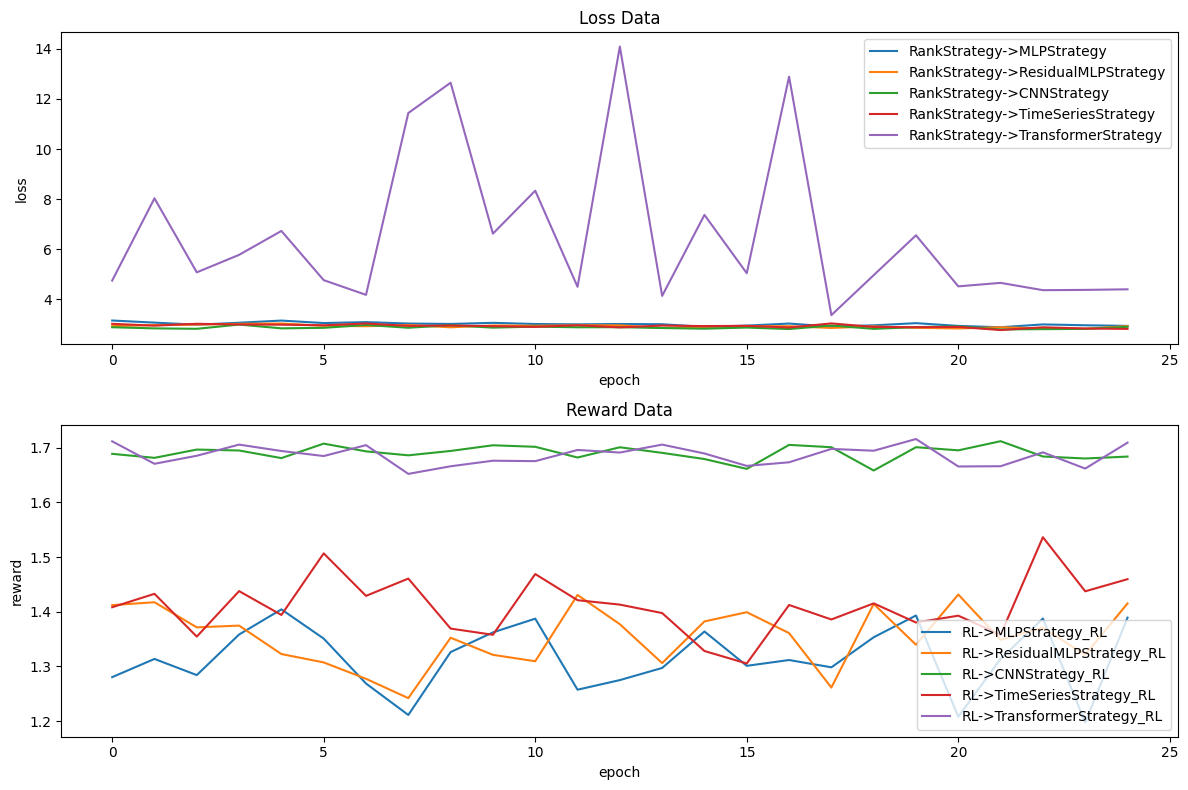

In [12]:
trainer.plot_graph()

In [13]:
RUN_SEED = 42
UB = None

run_experiment(RandomStrategy(), seed= RUN_SEED, ub=UB)
run_experiment(GreedyStrategy(), seed= RUN_SEED, ub=UB)
run_experiment(RankStrategy(), seed= RUN_SEED, ub=UB)


for model in (models + rl_models):
    AIGraph = TripartiteGraph(model, n_Inodes=n_Inodes)
    model.load()
    model.eval()

    run_experiment(AIGraph, seed= RUN_SEED, ub=UB)

Simulating: RankStrategy: 100%|██████████| 100/100 [00:00<00:00, 112.71it/s]


Model loaded from ./models/MLPStrategy.pth


Simulating: MLPStrategy: 100%|██████████| 100/100 [00:23<00:00,  4.28it/s]


Model loaded from ./models/ResidualMLPStrategy.pth


Simulating: ResidualMLPStrategy: 100%|██████████| 100/100 [00:27<00:00,  3.70it/s]


...

Simulating: CNNStrategy_RL: 100%|██████████| 100/100 [00:21<00:00,  4.74it/s]


Model loaded from ./models/TimeSeriesStrategy_RL.pth


Simulating: TimeSeriesStrategy_RL: 100%|██████████| 100/100 [00:20<00:00,  4.94it/s]


Model loaded from ./models/TransformerStrategy_RL.pth


Simulating: TransformerStrategy_RL: 100%|██████████| 100/100 [00:31<00:00,  3.16it/s]


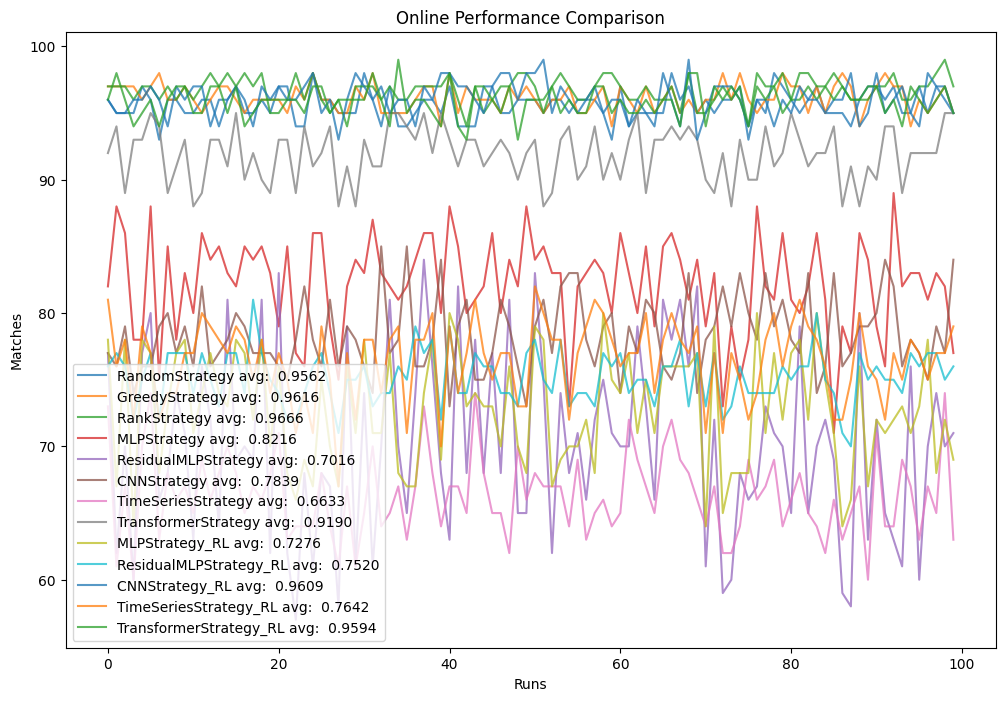

In [14]:
def plot_results(results:dict= RESULTS, optimal= OPTIMAL):
    plt.figure(figsize= (12, 8))
    for res in results:
        plt.plot(results[res], alpha=0.75, label=f"{res} avg: {np.average(results[res]) / optimal: .4f}")

    plt.title("Online Performance Comparison")
    plt.xlabel("Runs")
    plt.ylabel("Matches")

    plt.legend()
    plt.show()

plot_results()